<a href="https://colab.research.google.com/github/kanishkapal2005/CBSOT-INTERNSHIP/blob/main/AI_Powered_Maternal_Health_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost shap joblib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    learning_curve, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import shap
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")


All libraries imported successfully!


## 5. Data Loading


In [3]:
DATA_PATH = "/content/Maternal Health Risk Data Set.csv"
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
print(f"Dataset loaded successfully! Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded successfully! Shape: 1014 rows x 7 columns


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.00,98.0,86,high risk
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk
7,35,85,60,11.00,102.0,86,high risk
8,32,120,90,6.90,98.0,70,mid risk
9,42,130,80,18.00,98.0,70,high risk


## 6. Data Exploration


In [4]:
print("Dataset Shape (rows, columns):", df.shape)


Dataset Shape (rows, columns): (1014, 7)


In [5]:
print("Column Data Types:\n")
print(df.dtypes)


Column Data Types:

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print("Missing Value Report:\n")
print(missing_report)

if missing.sum() == 0:
    print("\n No missing values found in the dataset.")


Missing Value Report:

             Missing Count  Missing %
Age                      0        0.0
SystolicBP               0        0.0
DiastolicBP              0        0.0
BS                       0        0.0
BodyTemp                 0        0.0
HeartRate                0        0.0
RiskLevel                0        0.0

 No missing values found in the dataset.


In [8]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")


Number of duplicate rows: 562
Percentage of duplicates: 55.42%


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [10]:
print("RiskLevel value counts:\n")
print(df['RiskLevel'].value_counts())
print("\nRiskLevel proportions:\n")
print(df['RiskLevel'].value_counts(normalize=True).round(3) * 100)


RiskLevel value counts:

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

RiskLevel proportions:

RiskLevel
low risk     40.0
mid risk     33.1
high risk    26.8
Name: proportion, dtype: float64


## 7. Data Cleaning

**Cleaning steps performed:**
1. Remove exact duplicate rows (keeps the dataset statistically honest — duplicates
   can bias both EDA and model training).
2. Standardize the text in the `RiskLevel` column (trim whitespace, normalize case)
   so that downstream encoding is consistent.
3. Re-check for missing values after cleaning.
4. Reset the DataFrame index after dropping rows.


In [11]:
print(f"Shape before cleaning: {df.shape}")
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean['RiskLevel'] = df_clean['RiskLevel'].astype(str).str.strip().str.lower()
assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values found!"
print(f"Shape after removing duplicates: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print("\nUnique RiskLevel categories after cleaning:", df_clean['RiskLevel'].unique())
df = df_clean.copy()
df.head()


Shape before cleaning: (1014, 7)
Shape after removing duplicates: (452, 7)
Rows removed: 562

Unique RiskLevel categories after cleaning: ['high risk' 'low risk' 'mid risk']


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 8. Exploratory Data Analysis (EDA)

This section visually explores the relationships between clinical features and
the target `RiskLevel`, helping us understand which factors might drive risk.


### 8.1 Class Distribution

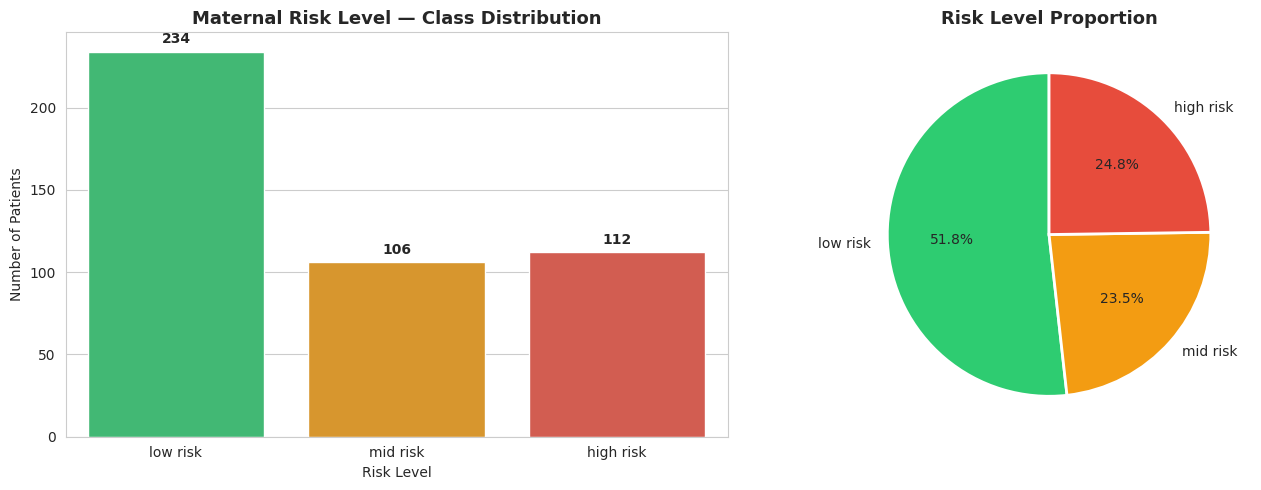

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_order = ['low risk', 'mid risk', 'high risk']
risk_counts = df['RiskLevel'].value_counts().reindex(risk_order)
sns.barplot(x=risk_counts.index, y=risk_counts.values,
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Maternal Risk Level — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Risk Level Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
fig = px.bar(x=risk_counts.index, y=risk_counts.values,
             labels={'x': 'Risk Level', 'y': 'Number of Patients'},
             title='Interactive View — Maternal Risk Level Distribution',
             color=risk_counts.index,
             color_discrete_map={'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'})
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()


### 8.2 Correlation Heatmap

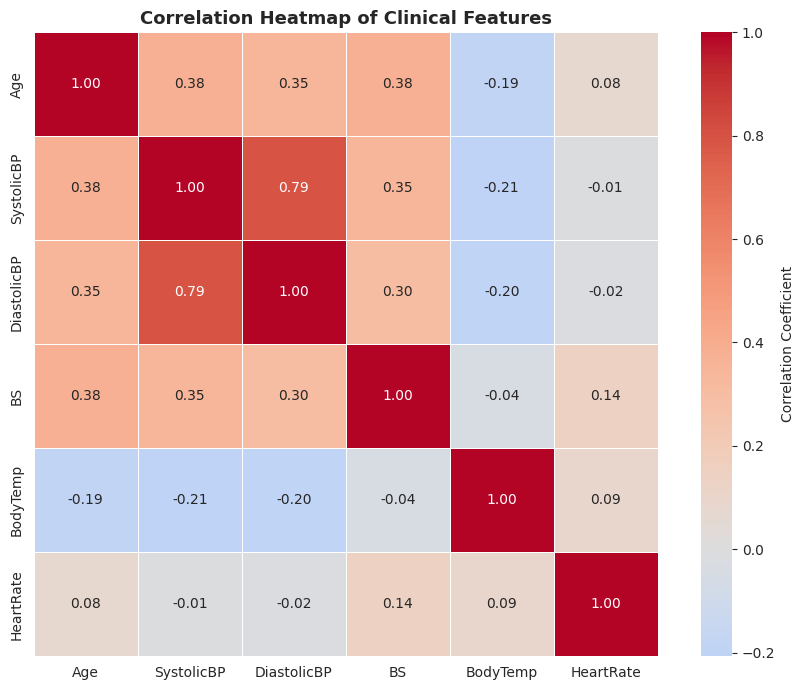

In [14]:
numeric_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

plt.figure(figsize=(9, 7))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Clinical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.3 Feature Distribution Plots

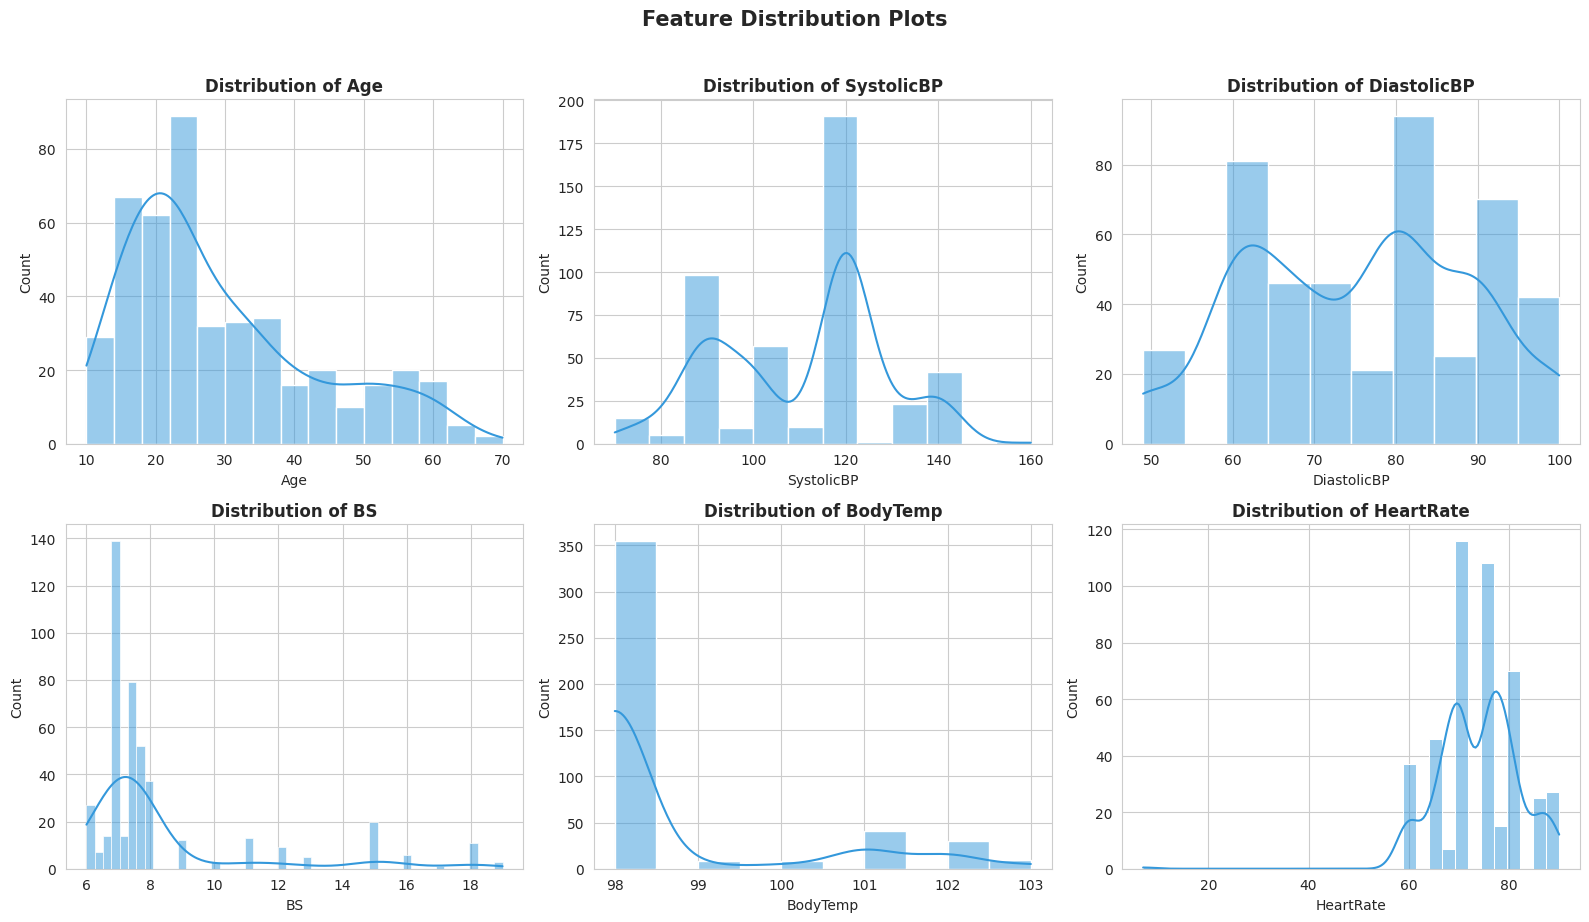

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3498db')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)

plt.suptitle('Feature Distribution Plots', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 8.4 Boxplots — Outlier Analysis

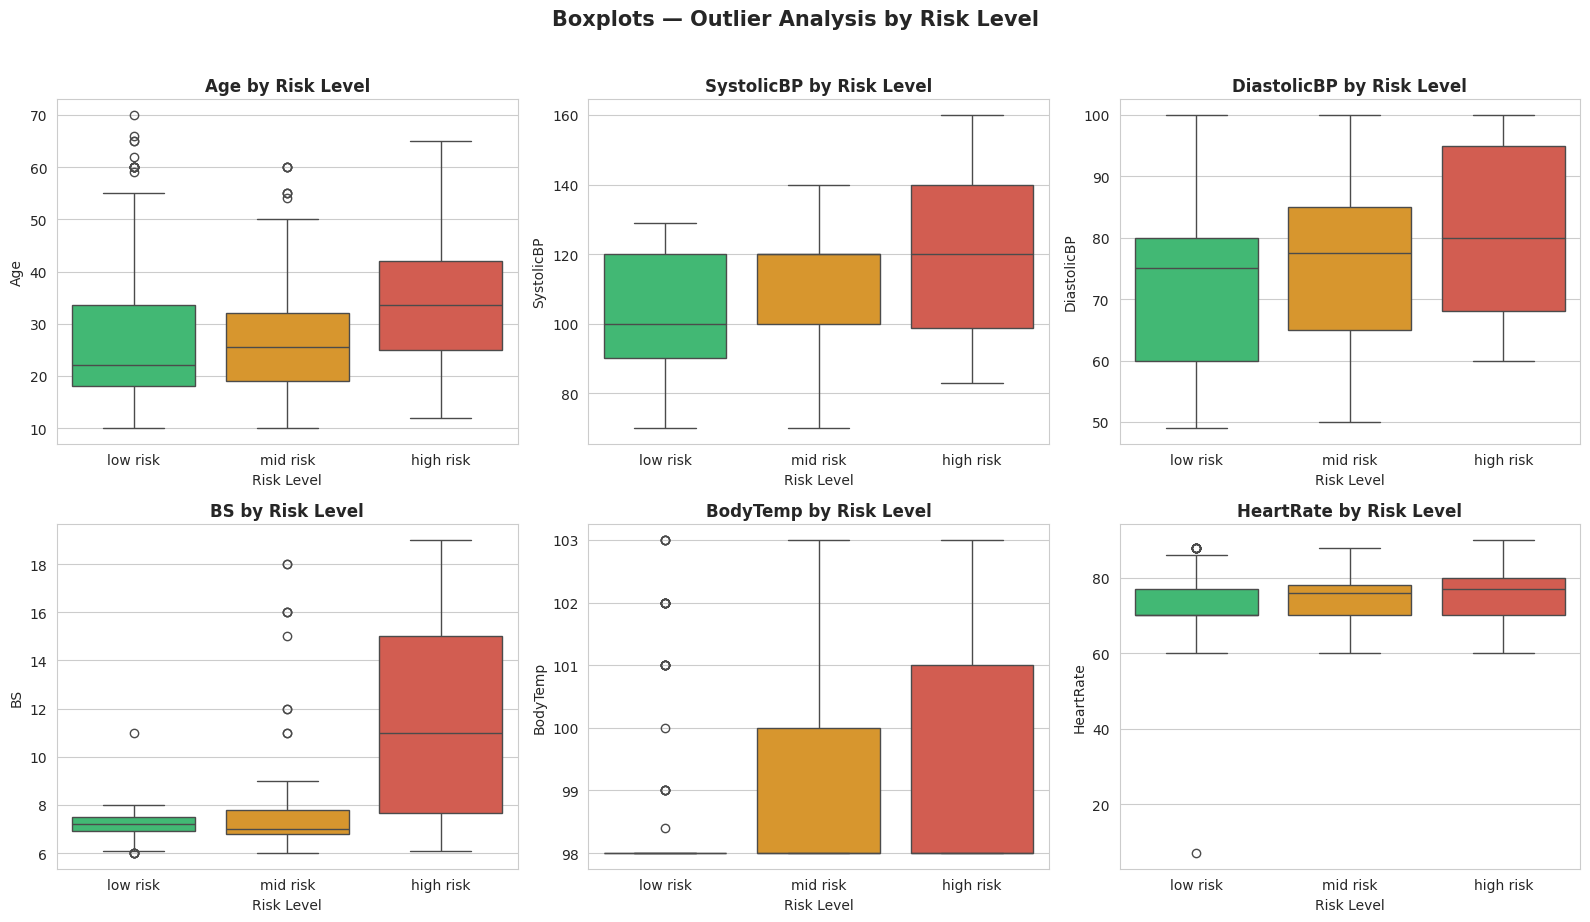

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='RiskLevel', y=col, data=df, order=risk_order,
                palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} by Risk Level', fontweight='bold')
    axes[i].set_xlabel('Risk Level')

plt.suptitle('Boxplots — Outlier Analysis by Risk Level', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [17]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_report = pd.DataFrame({
    'Feature': numeric_cols,
    'Outlier Count (IQR method)': [count_outliers_iqr(df[c]) for c in numeric_cols]
})
outlier_report


,Feature,Outlier Count (IQR method)
0,Age,23
1,SystolicBP,0
2,DiastolicBP,0
3,BS,71
4,BodyTemp,98
5,HeartRate,1


### 8.5 Pairplot

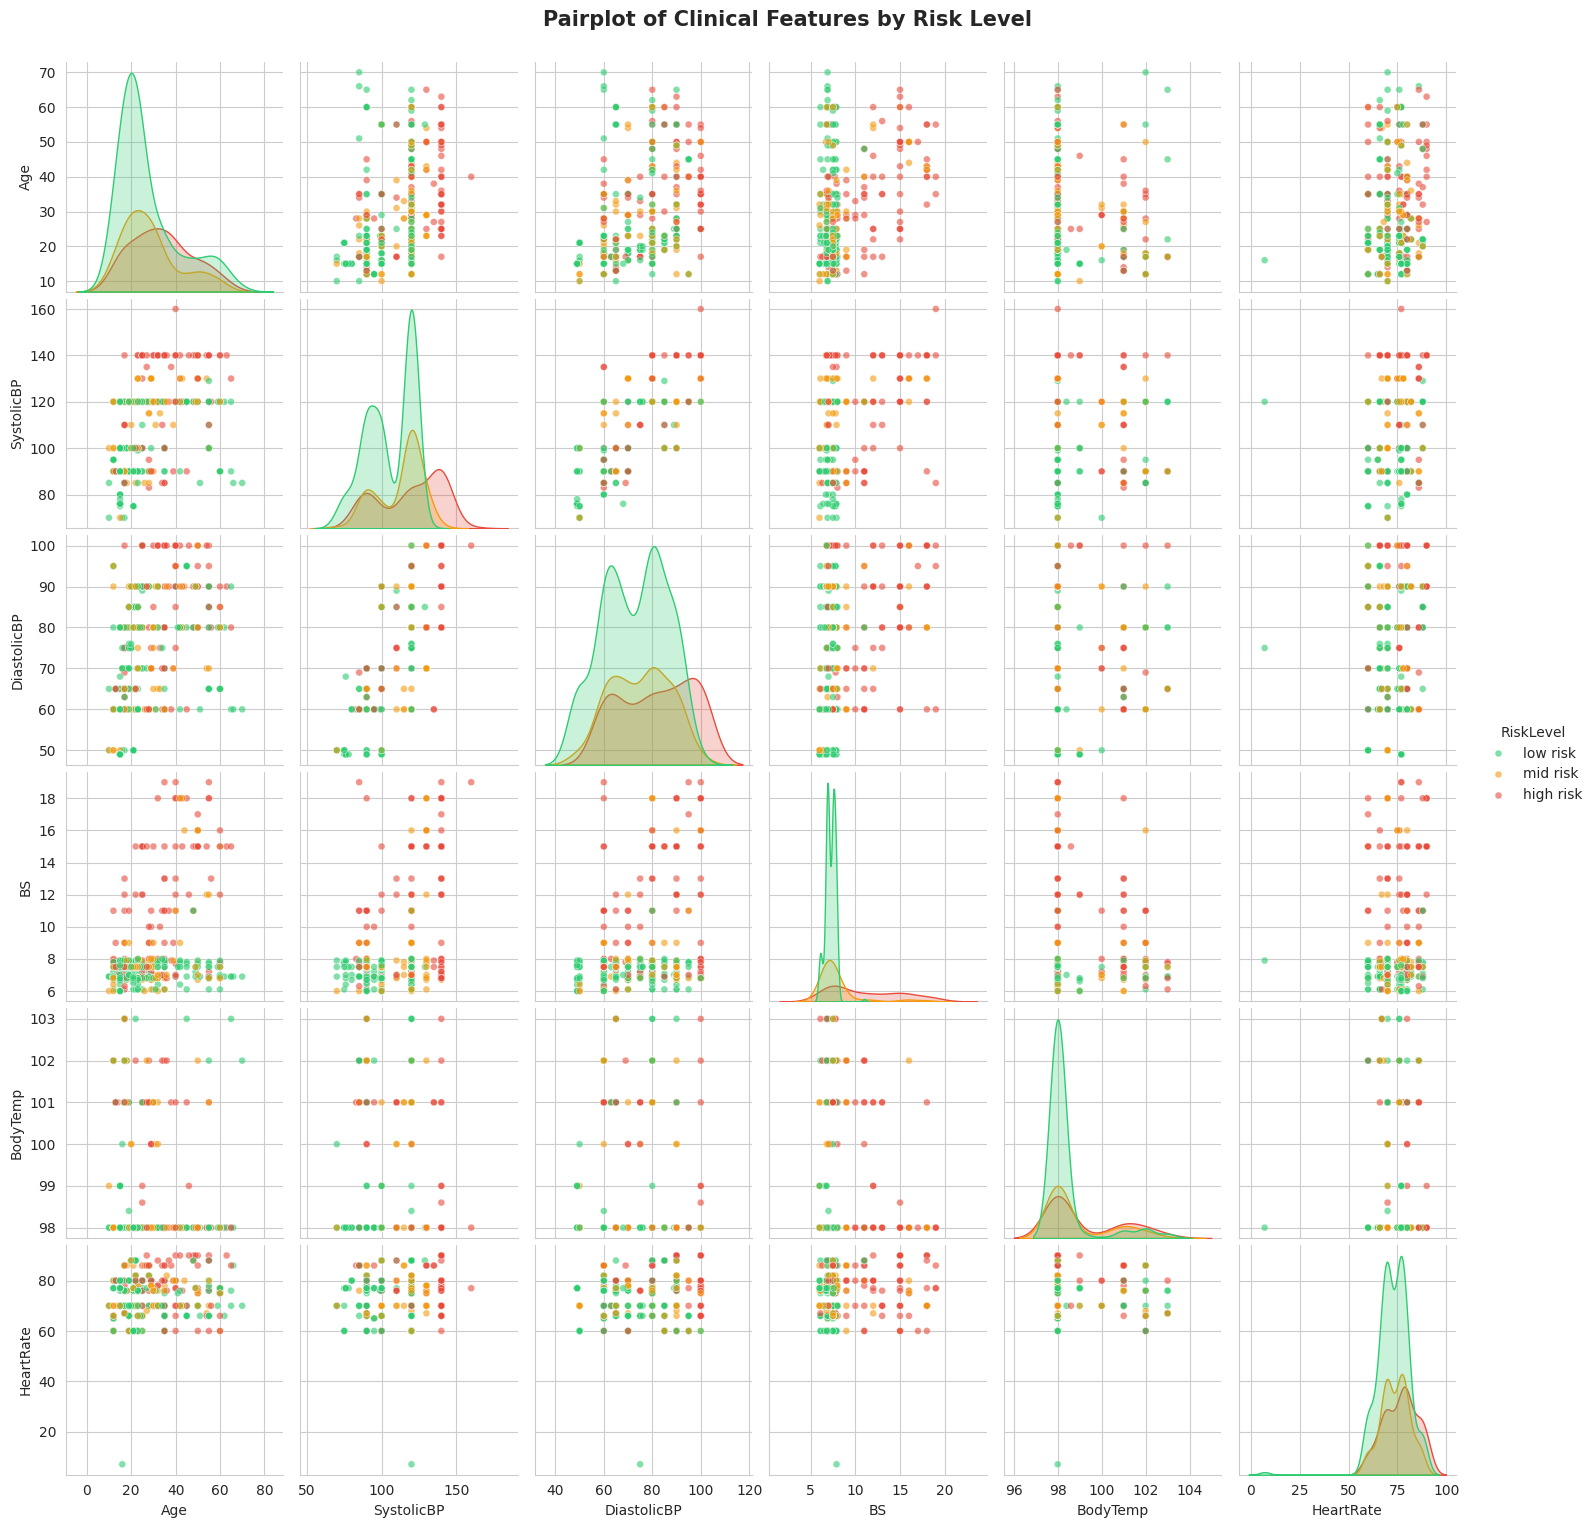

In [18]:
sns.pairplot(df, vars=numeric_cols, hue='RiskLevel', hue_order=risk_order,
             palette=['#2ecc71', '#f39c12', '#e74c3c'], diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 25})
plt.suptitle('Pairplot of Clinical Features by Risk Level', y=1.02, fontsize=15, fontweight='bold')
plt.show()


### 8.6 Risk Level Comparison Graphs

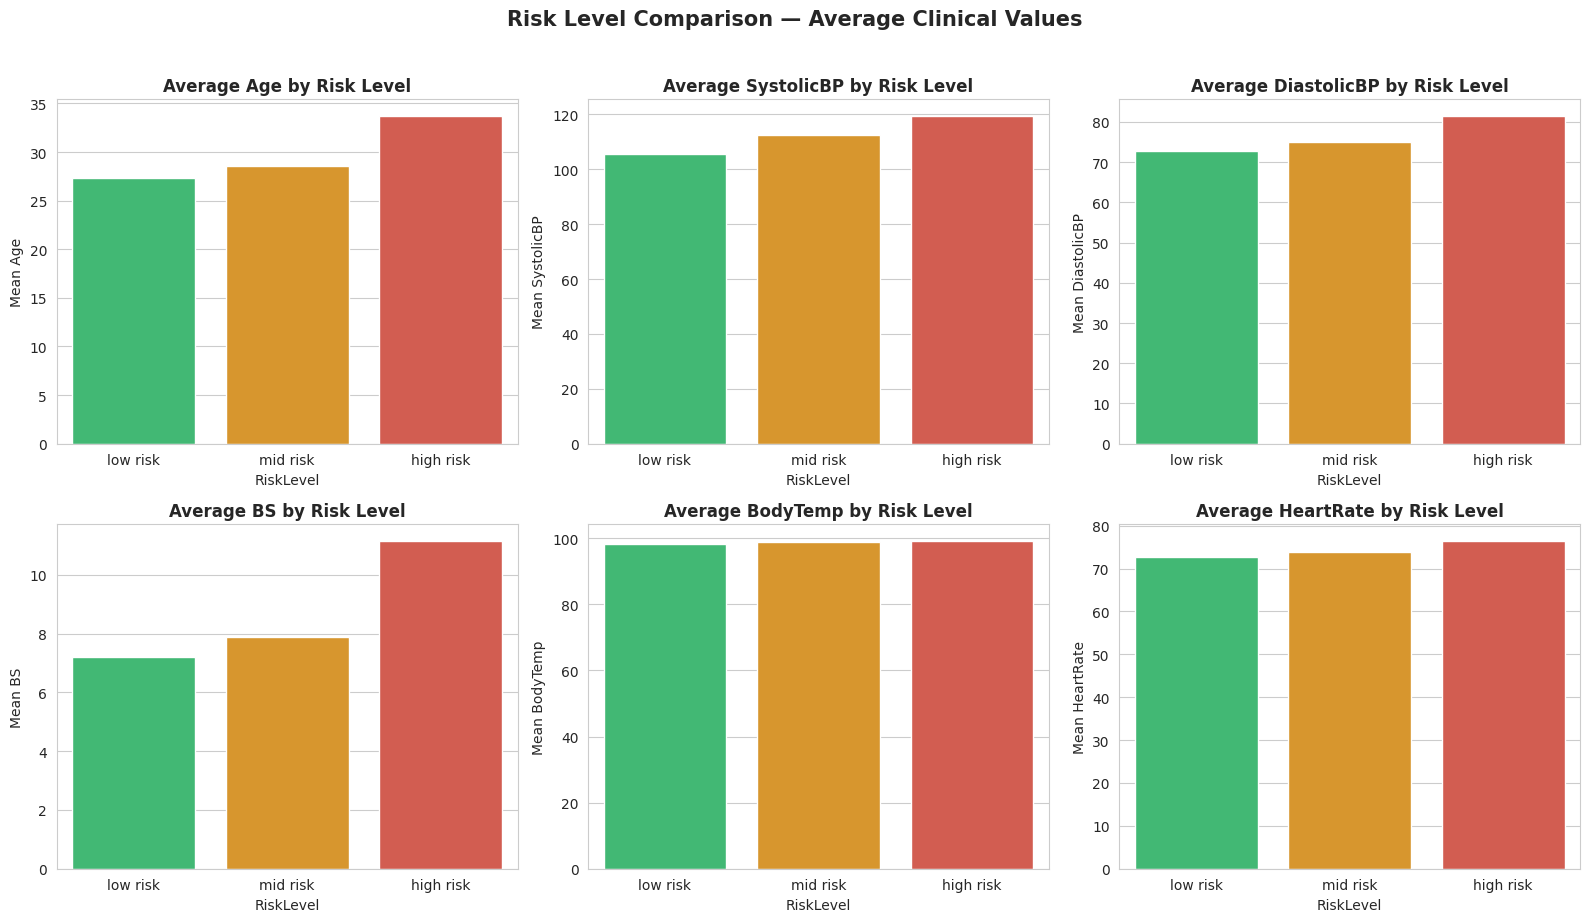

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,27.320513,105.435897,72.730769,7.201838,98.360684,72.760684
mid risk,28.537736,112.405660,74.886792,7.893585,98.858491,73.896226
high risk,33.732143,119.491071,81.535714,11.165357,99.228571,76.482143


In [19]:
risk_means = df.groupby('RiskLevel')[numeric_cols].mean().reindex(risk_order)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.barplot(x=risk_means.index, y=risk_means[col],
                palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Average {col} by Risk Level', fontweight='bold')
    axes[i].set_ylabel(f'Mean {col}')

plt.suptitle('Risk Level Comparison — Average Clinical Values', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

risk_means


In [20]:
risk_means_long = risk_means.reset_index().melt(id_vars='RiskLevel',
                                                  var_name='Feature', value_name='Mean Value')
fig = px.bar(risk_means_long, x='Feature', y='Mean Value', color='RiskLevel',
             barmode='group', title='Average Clinical Feature Values by Risk Level',
             color_discrete_map={'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'})
fig.update_layout(title_x=0.5)
fig.show()


## 9. Feature Engineering

We derive two additional clinically meaningful features from the raw vitals:

- **Pulse Pressure** = `SystolicBP - DiastolicBP` — a known indicator of
  arterial stiffness and cardiovascular risk.
- **Mean Arterial Pressure (MAP)** = `DiastolicBP + (SystolicBP - DiastolicBP) / 3`
  — the average pressure in a patient's arteries during one cardiac cycle, widely
  used in clinical risk assessment.

Both are computed directly from inputs already collected, so they add predictive
signal without requiring any new measurements — and the same formulas are reused
later inside the live Risk Prediction System.


In [21]:
def engineer_features(data):
    '''Add derived clinical features to a DataFrame containing the 6 raw vitals.'''
    data = data.copy()
    data['PulsePressure'] = data['SystolicBP'] - data['DiastolicBP']
    data['MAP'] = data['DiastolicBP'] + (data['SystolicBP'] - data['DiastolicBP']) / 3
    return data

df = engineer_features(df)
print("New features added: 'PulsePressure', 'MAP'")
df[['SystolicBP', 'DiastolicBP', 'PulsePressure', 'MAP']].head()


New features added: 'PulsePressure', 'MAP'


,SystolicBP,DiastolicBP,PulsePressure,MAP
0,130,80,50,96.666667
1,140,90,50,106.666667
2,90,70,20,76.666667
3,140,85,55,103.333333
4,120,60,60,80.000000


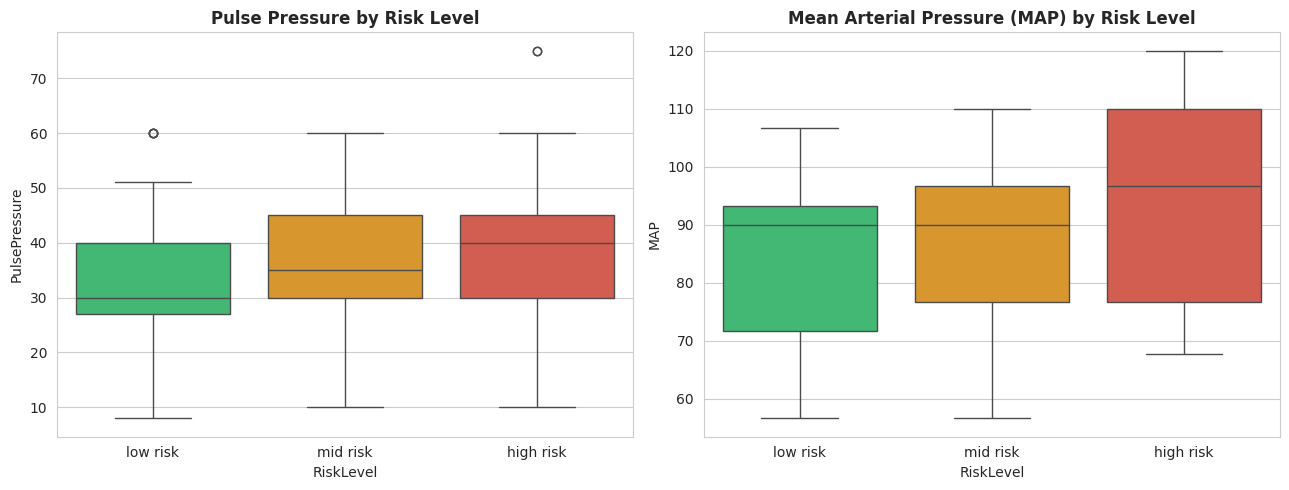

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='RiskLevel', y='PulsePressure', data=df, order=risk_order,
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Pulse Pressure by Risk Level', fontweight='bold')

sns.boxplot(x='RiskLevel', y='MAP', data=df, order=risk_order,
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1])
axes[1].set_title('Mean Arterial Pressure (MAP) by Risk Level', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Data Preprocessing

**Steps:**
1. **Label Encoding** of the target — mapped explicitly (not via default
   alphabetical `LabelEncoder`) so the classes preserve their natural risk
   ordering: `0 = Low Risk, 1 = Mid Risk, 2 = High Risk`.
2. **Feature/target split** — `X` contains all 8 clinical + engineered features,
   `y` is the encoded `RiskLevel`.
3. **Train-Test Split (80:20)**, stratified on `y` to preserve class proportions
   in both sets.
4. **Feature Scaling** with `StandardScaler` — fit only on the training data to
   avoid data leakage, then applied to both train and test sets.


In [23]:
# Step 1: Explicit, ordinal-aware label encoding
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel_Encoded'] = df['RiskLevel'].map(risk_mapping)

print("Encoding map used:", risk_mapping)
df[['RiskLevel', 'RiskLevel_Encoded']].drop_duplicates().sort_values('RiskLevel_Encoded')


Encoding map used: {'low risk': 0, 'mid risk': 1, 'high risk': 2}


,RiskLevel,RiskLevel_Encoded
4,low risk,0
6,mid risk,1
0,high risk,2


In [24]:
# Step 2: Define feature matrix (X) and target vector (y)
FEATURE_COLUMNS = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp',
                    'HeartRate', 'PulsePressure', 'MAP']

X = df[FEATURE_COLUMNS]
y = df['RiskLevel_Encoded']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Features used:", FEATURE_COLUMNS)


Feature matrix shape: (452, 8)
Target vector shape: (452,)
Features used: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'PulsePressure', 'MAP']


In [25]:
# Step 3: Train-Test Split (80% train, 20% test), stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")
print("\nClass balance check (proportions):")
print("Train:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest:\n", y_test.value_counts(normalize=True).round(3))


Training set size: 361 samples
Test set size:     91 samples

Class balance check (proportions):
Train:
 RiskLevel_Encoded
0    0.518
2    0.247
1    0.235
Name: proportion, dtype: float64

Test:
 RiskLevel_Encoded
0    0.516
2    0.253
1    0.231
Name: proportion, dtype: float64


In [26]:
# Step 4: Feature Scaling — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep scaled versions as DataFrames (useful later for SHAP / feature names)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS, index=X_test.index)

print(" Features scaled using StandardScaler (mean=0, std=1 on training data).")
X_train_scaled_df.describe().T[['mean', 'std']]


 Features scaled using StandardScaler (mean=0, std=1 on training data).


,mean,std
Age,5.904787e-17,1.001388
SystolicBP,-1.820643e-16,1.001388
DiastolicBP,-3.063108e-16,1.001388
BS,2.165089e-16,1.001388
BodyTemp,-4.069383e-15,1.001388
HeartRate,-1.623817e-16,1.001388
PulsePressure,1.574610e-16,1.001388
MAP,4.920656e-18,1.001388


## 11. Model Training

We train **7 classification algorithms** on the same train/test split so that
comparisons are fair:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost
6. K-Nearest Neighbors
7. Support Vector Machine (SVM)

Each model is wrapped in a dictionary so we can loop over training, prediction,
and evaluation in a modular way.


In [27]:
# Define every model with a fixed random_state for reproducibility
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine': SVC(probability=True, random_state=42)
}

trained_models = {}     # stores fitted model objects
predictions = {}        # stores test-set predictions
prediction_probs = {}   # stores predicted probabilities

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    prediction_probs[name] = model.predict_proba(X_test_scaled)
    print(f" Trained: {name}")

print("\nAll 7 models trained successfully!")


 Trained: Logistic Regression
 Trained: Decision Tree
 Trained: Random Forest
 Trained: Gradient Boosting
 Trained: XGBoost
 Trained: K-Nearest Neighbors
 Trained: Support Vector Machine

All 7 models trained successfully!


## 12. Model Evaluation

For every model we compute **Accuracy, Precision, Recall, and F1-Score**
(weighted average, to fairly account for class imbalance), then visualize
**confusion matrices** and print the full **classification report**.


In [28]:
# Build a comparison table of core metrics for every model
results = []
for name in models.keys():
    y_pred = predictions[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.725275,0.685515,0.725275,0.676504
1,K-Nearest Neighbors,0.703297,0.678168,0.703297,0.681528
2,Logistic Regression,0.681319,0.660810,0.681319,0.639305
3,Random Forest,0.659341,0.613422,0.659341,0.629923
4,Decision Tree,0.648352,0.651380,0.648352,0.649387
5,XGBoost,0.637363,0.595432,0.637363,0.612281
6,Gradient Boosting,0.637363,0.598291,0.637363,0.614253


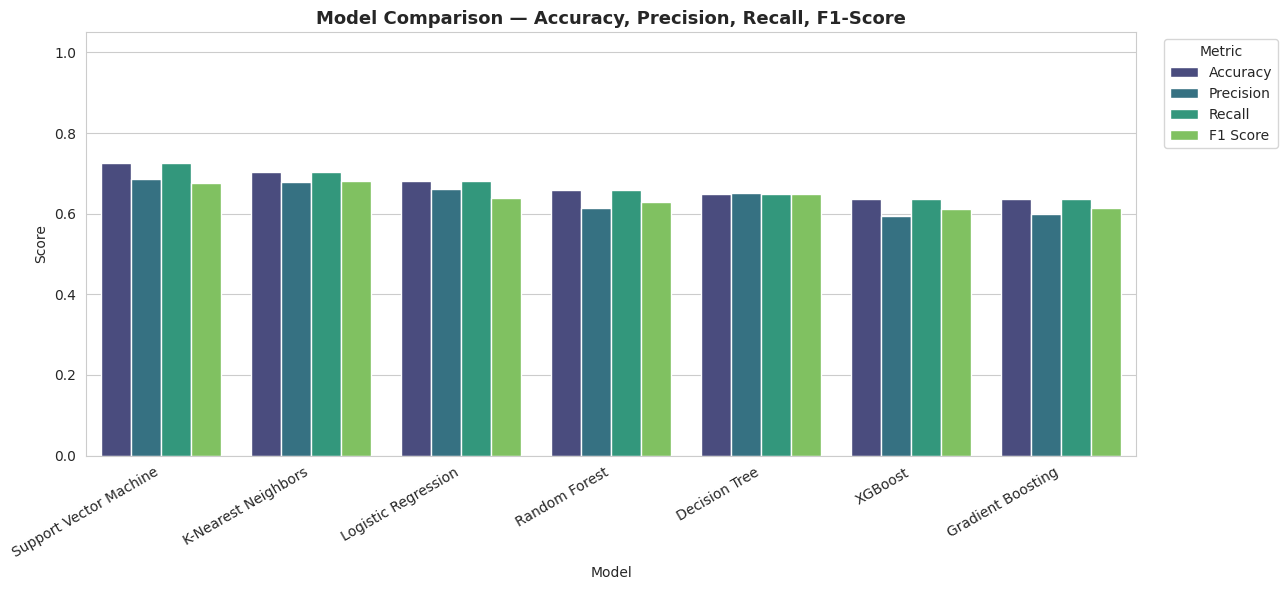

In [29]:
# Visual comparison of all metrics across models
metrics_long = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(13, 6))
sns.barplot(data=metrics_long, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison — Accuracy, Precision, Recall, F1-Score', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


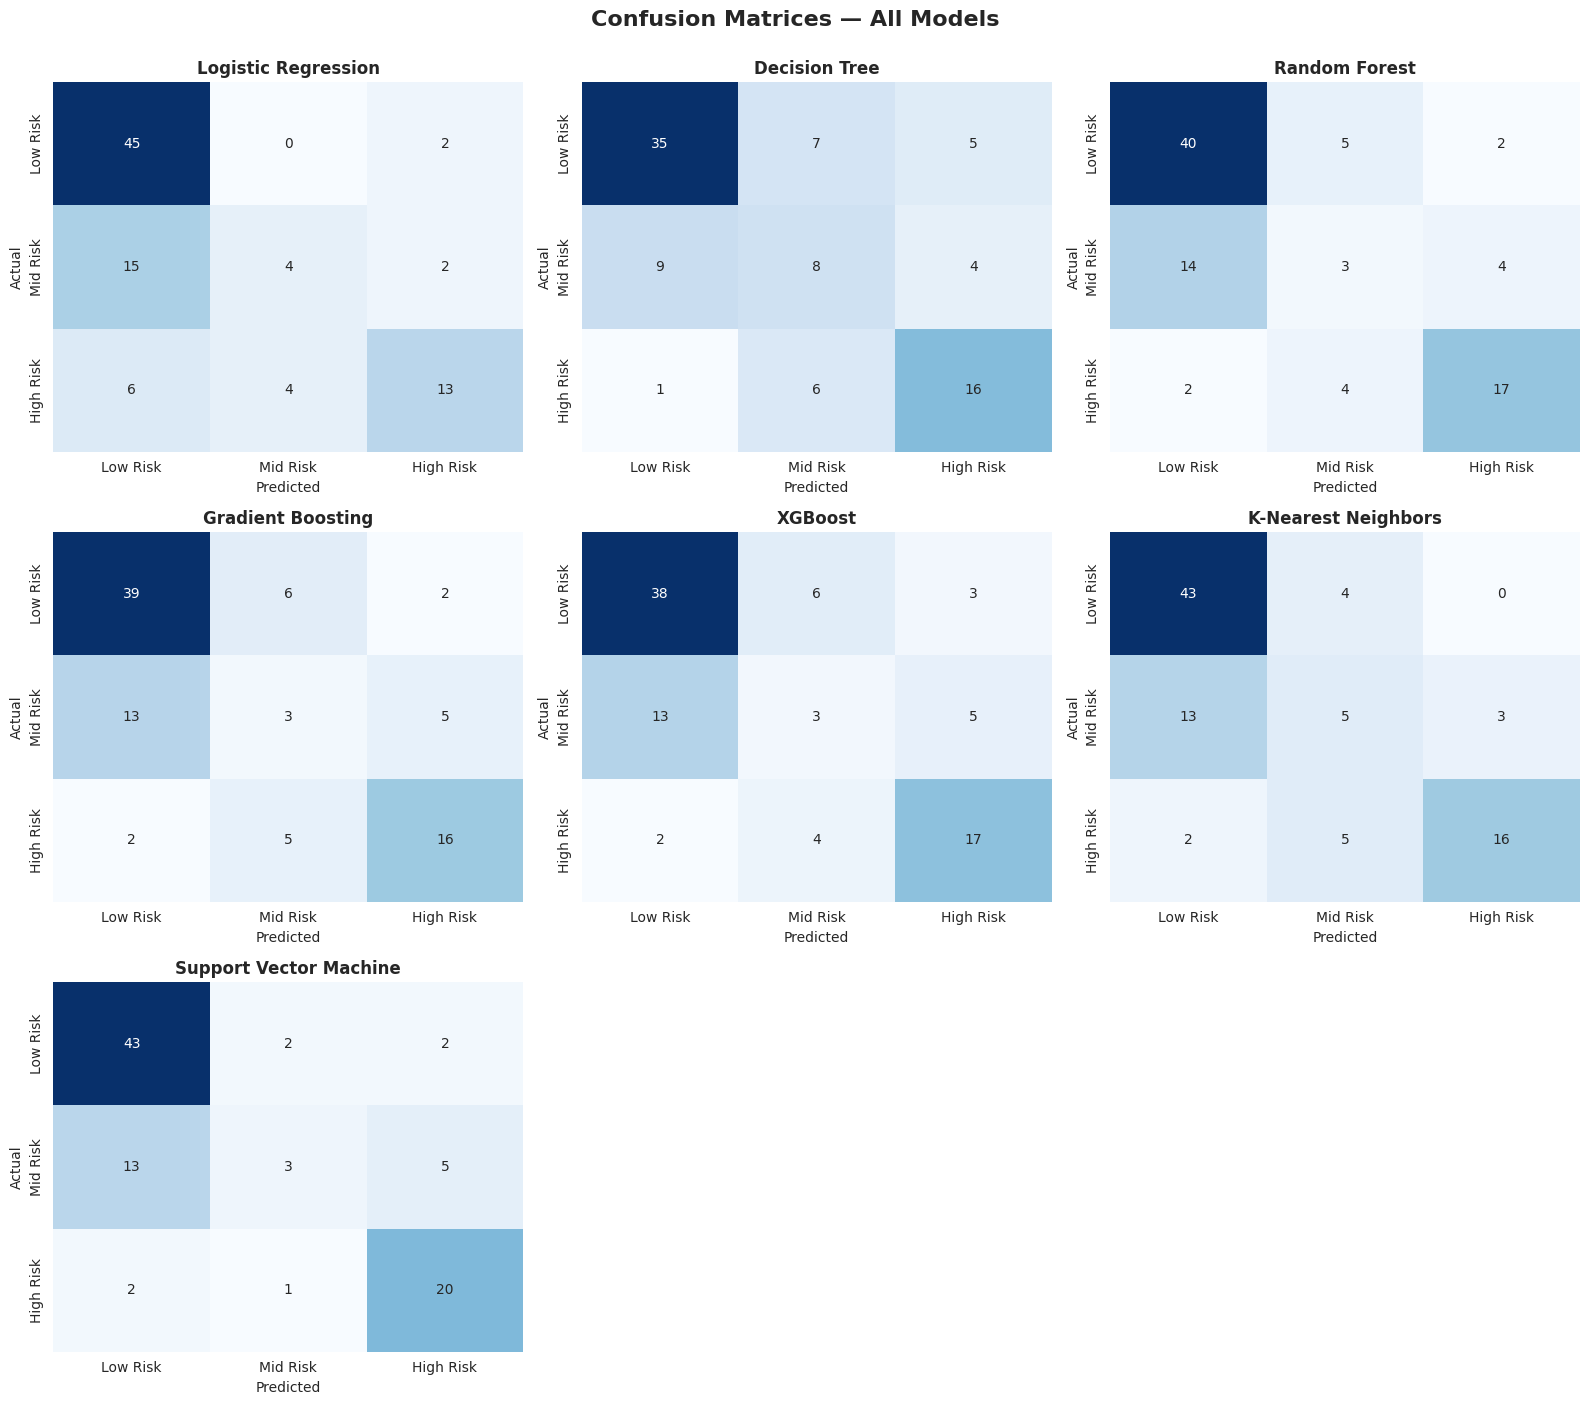

In [30]:
# Confusion matrix for every model
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
labels = ['Low Risk', 'Mid Risk', 'High Risk']

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=axes[i], cbar=False)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused subplots (we have 7 models, 9 grid slots)
for j in range(len(models), len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


In [31]:
# Full classification report for every model
for name in models.keys():
    print(f"{'='*60}\nClassification Report: {name}\n{'='*60}")
    print(classification_report(y_test, predictions[name], target_names=labels))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    Low Risk       0.68      0.96      0.80        47
    Mid Risk       0.50      0.19      0.28        21
   High Risk       0.76      0.57      0.65        23

    accuracy                           0.68        91
   macro avg       0.65      0.57      0.57        91
weighted avg       0.66      0.68      0.64        91

Classification Report: Decision Tree
              precision    recall  f1-score   support

    Low Risk       0.78      0.74      0.76        47
    Mid Risk       0.38      0.38      0.38        21
   High Risk       0.64      0.70      0.67        23

    accuracy                           0.65        91
   macro avg       0.60      0.61      0.60        91
weighted avg       0.65      0.65      0.65        91

Classification Report: Random Forest
              precision    recall  f1-score   support

    Low Risk       0.71      0.85      0.78        47
    Mid Risk

In [32]:
# Identify the best-performing model (highest F1-score, ties broken by accuracy)
best_model_name = results_df.sort_values(['F1 Score', 'Accuracy'], ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f" Best-performing model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])


 Best-performing model: K-Nearest Neighbors
                 Model  Accuracy  Precision    Recall  F1 Score
1  K-Nearest Neighbors  0.703297   0.678168  0.703297  0.681528


## 13. Explainable AI

A model that simply says *"High Risk"* is not enough in a clinical setting —
practitioners need to know **why**. We use two complementary techniques:

1. **Feature Importance** — global ranking of which features matter most,
   straight from the tree-based models.
2. **SHAP (SHapley Additive exPlanations)** — a game-theoretic approach that
   explains both global feature impact and individual predictions.

We use the **Random Forest** model as the reference model for explainability
plots, since tree ensembles pair well with fast, exact SHAP `TreeExplainer`
computations and are highly interpretable.


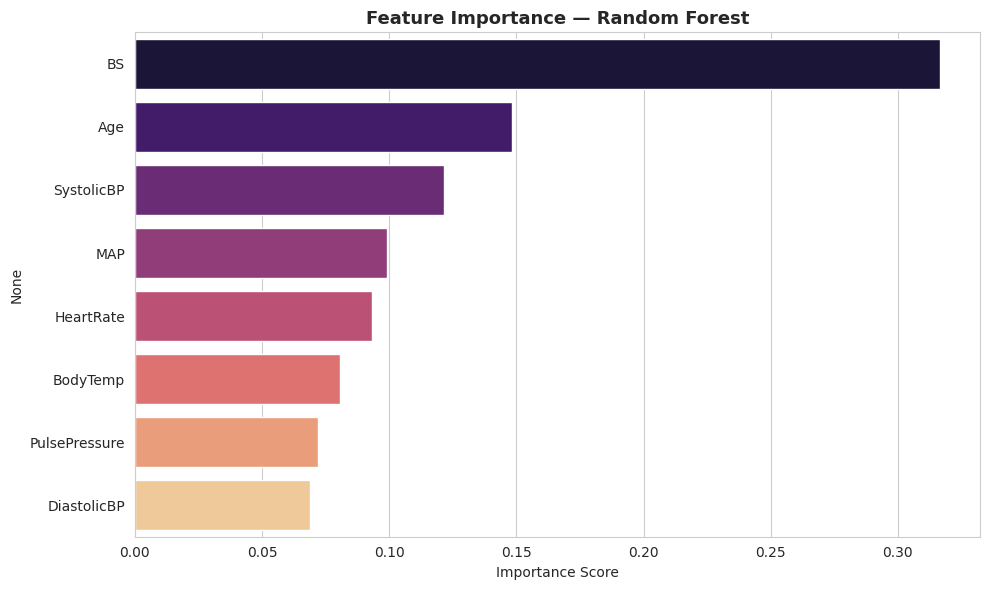

,0
BS,0.316454
Age,0.148326
SystolicBP,0.121492
MAP,0.098991
HeartRate,0.093228
BodyTemp,0.080653
PulsePressure,0.071969
DiastolicBP,0.068887


In [33]:
# ---- Feature Importance (Random Forest) ----
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLUMNS)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

importances


In [34]:
# ---- SHAP Explainability ----
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled_df)

# Handle both legacy (list-of-arrays) and modern (3D array) SHAP output formats
HIGH_RISK_CLASS_INDEX = 2

if isinstance(shap_values, list):
    shap_values_high_risk = shap_values[HIGH_RISK_CLASS_INDEX]
else:
    shap_values_high_risk = shap_values[:, :, HIGH_RISK_CLASS_INDEX]

print("SHAP values computed for the 'High Risk' class.")
print("Shape:", np.array(shap_values_high_risk).shape)


SHAP values computed for the 'High Risk' class.
Shape: (91, 8)


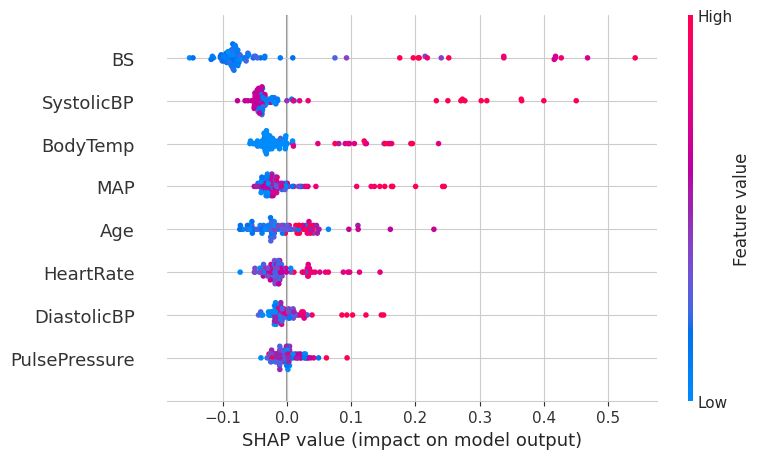

In [35]:

shap.summary_plot(shap_values_high_risk, X_test_scaled_df, show=True)


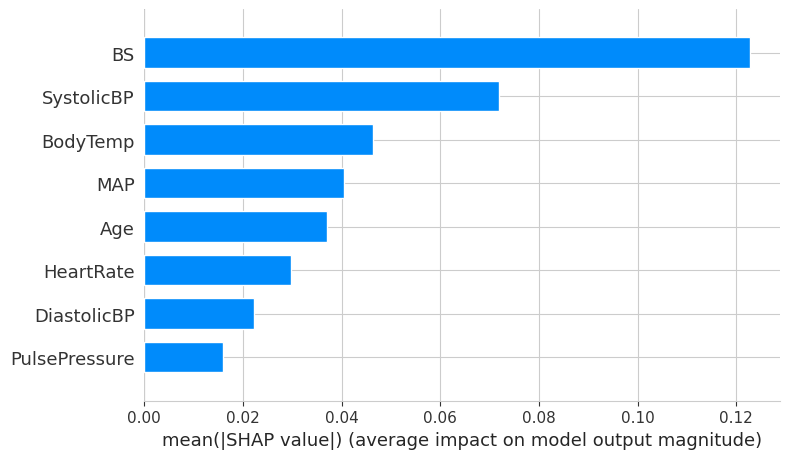

In [36]:

shap.summary_plot(shap_values_high_risk, X_test_scaled_df, plot_type='bar', show=True)


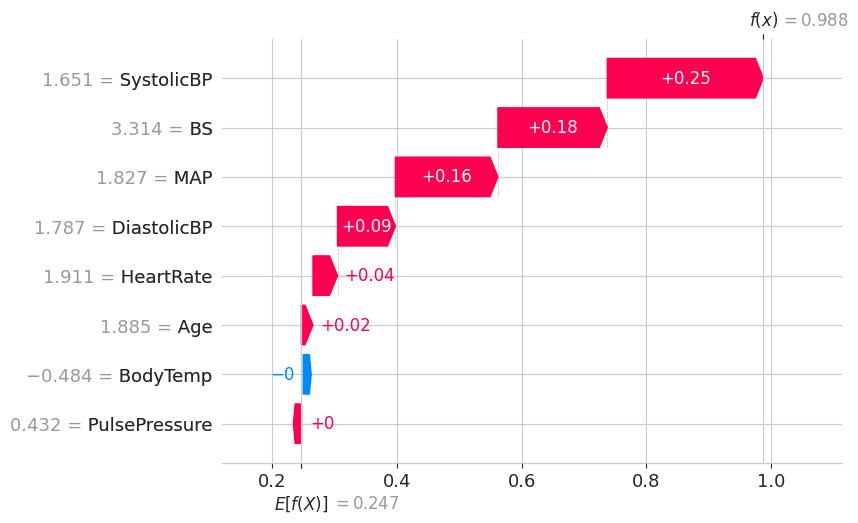

In [37]:

sample_idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=np.array(shap_values_high_risk)[sample_idx],
        base_values=explainer.expected_value[HIGH_RISK_CLASS_INDEX]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value,
        data=X_test_scaled_df.iloc[sample_idx].values,
        feature_names=FEATURE_COLUMNS
    )
)


**Clinical interpretation:** Across most maternal-risk studies (and consistent
with the importance/SHAP plots above), **Blood Sugar (BS)**, **Systolic/Diastolic
Blood Pressure**, and **Age** tend to be the strongest drivers of high risk
classification, followed by Body Temperature and Heart Rate. The derived **MAP**
and **Pulse Pressure** features often add incremental signal on top of the raw
BP readings.


## 14. AI-Powered Risk Prediction System

This section implements a reusable function (and a simple interactive widget)
that takes a patient's 6 raw vitals, automatically derives `PulsePressure` and
`MAP`, scales the inputs using the **same fitted scaler** from training, and
returns a predicted risk level with probability scores for all 3 classes.


In [38]:
def predict_maternal_risk(age, systolic_bp, diastolic_bp, blood_sugar, body_temp,
                            heart_rate, model=None, scaler_obj=None):
    '''
    Predict maternal health risk level from 6 raw clinical inputs.

    Returns a dict with the predicted label and probability for each class.
    '''
    model = model if model is not None else best_model
    scaler_obj = scaler_obj if scaler_obj is not None else scaler

    raw = pd.DataFrame([{
        'Age': age,
        'SystolicBP': systolic_bp,
        'DiastolicBP': diastolic_bp,
        'BS': blood_sugar,
        'BodyTemp': body_temp,
        'HeartRate': heart_rate
    }])
    raw = engineer_features(raw)
    raw = raw[FEATURE_COLUMNS]

    raw_scaled = scaler_obj.transform(raw)

    pred_class = model.predict(raw_scaled)[0]
    pred_probs = model.predict_proba(raw_scaled)[0]

    inverse_mapping = {0: 'Low Risk', 1: 'Mid Risk', 2: 'High Risk'}

    return {
        'predicted_risk': inverse_mapping[pred_class],
        'probabilities': {
            'Low Risk': round(pred_probs[0] * 100, 2),
            'Mid Risk': round(pred_probs[1] * 100, 2),
            'High Risk': round(pred_probs[2] * 100, 2)
        }
    }


# ---- Example usage ----
example_result = predict_maternal_risk(
    age=35, systolic_bp=140, diastolic_bp=95, blood_sugar=8.5,
    body_temp=101.0, heart_rate=88
)

print("Predicted Risk Level:", example_result['predicted_risk'])
print("Probability Breakdown:")
for risk, prob in example_result['probabilities'].items():
    print(f"   {risk}: {prob}%")


Predicted Risk Level: High Risk
Probability Breakdown:
   Low Risk: 14.29%
   Mid Risk: 28.57%
   High Risk: 57.14%


In [39]:
# ---- Interactive prediction widget
import ipywidgets as widgets
from IPython.display import display, clear_output

age_w = widgets.IntSlider(value=28, min=10, max=70, description='Age:')
sbp_w = widgets.IntSlider(value=120, min=70, max=200, description='Systolic BP:')
dbp_w = widgets.IntSlider(value=80, min=40, max=140, description='Diastolic BP:')
bs_w = widgets.FloatSlider(value=7.0, min=4.0, max=20.0, step=0.1, description='Blood Sugar:')
temp_w = widgets.FloatSlider(value=98.0, min=96.0, max=103.0, step=0.1, description='Body Temp (°F):')
hr_w = widgets.IntSlider(value=75, min=50, max=130, description='Heart Rate:')

predict_button = widgets.Button(description='🔍 Predict Risk', button_style='success')
output_area = widgets.Output()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        result = predict_maternal_risk(
            age=age_w.value, systolic_bp=sbp_w.value, diastolic_bp=dbp_w.value,
            blood_sugar=bs_w.value, body_temp=temp_w.value, heart_rate=hr_w.value
        )
        risk = result['predicted_risk']
        color = {'Low Risk': 'green', 'Mid Risk': 'orange', 'High Risk': 'red'}[risk]
        print(f"PREDICTED RISK LEVEL: {risk}\n")
        print("Probability Breakdown:")
        for r, p in result['probabilities'].items():
            print(f"   {r:<10}: {p}%")

predict_button.on_click(on_predict_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>🩺 Enter Patient Vitals</h3>"),
    age_w, sbp_w, dbp_w, bs_w, temp_w, hr_w, predict_button, output_area
]))


## 15. Healthcare Recommendation Engine

A simple rule-based engine that maps the predicted risk level to a set of
actionable healthcare recommendations.

> ⚠️ **Disclaimer:** These recommendations are illustrative and for
> educational/demo purposes only. They are **not** a substitute for
> professional medical advice — any real deployment must be reviewed and
> approved by licensed healthcare professionals.


In [40]:
def get_healthcare_recommendations(risk_level):
    '''Return a list of recommendation strings for a given risk level.'''
    recommendations = {
        'High Risk': [
            "Immediate medical consultation recommended.",
            "Monitor blood pressure daily.",
            "Monitor blood sugar regularly.",
            "Schedule prenatal checkups promptly.",
            "Consider hospital-based monitoring if symptoms worsen."
        ],
        'Mid Risk': [
            "Maintain a healthy, balanced diet.",
            "Monitor vital signs weekly.",
            "Follow physician guidance closely.",
            "Stay well hydrated and rested."
        ],
        'Low Risk': [
            "Continue routine prenatal care.",
            "Maintain a healthy, active lifestyle.",
            "Attend scheduled checkups as planned."
        ]
    }
    return recommendations.get(risk_level, ["No recommendations available for this risk level."])


# ---- Example ----
for risk in ['Low Risk', 'Mid Risk', 'High Risk']:
    print(f"\n{risk} Recommendations:")
    for rec in get_healthcare_recommendations(risk):
        print(f"  • {rec}")



Low Risk Recommendations:
  • Continue routine prenatal care.
  • Maintain a healthy, active lifestyle.
  • Attend scheduled checkups as planned.

Mid Risk Recommendations:
  • Maintain a healthy, balanced diet.
  • Monitor vital signs weekly.
  • Follow physician guidance closely.
  • Stay well hydrated and rested.

High Risk Recommendations:
  • Immediate medical consultation recommended.
  • Monitor blood pressure daily.
  • Monitor blood sugar regularly.
  • Schedule prenatal checkups promptly.
  • Consider hospital-based monitoring if symptoms worsen.


## 16. Patient Health Report Generator

Combines the prediction system and the recommendation engine into a single,
formatted patient report — similar to what a clinical decision-support tool
might display.


In [41]:
def generate_patient_report(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    '''Generate and print a formatted patient health report.'''
    result = predict_maternal_risk(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate)
    risk_level = result['predicted_risk']
    probs = result['probabilities']
    recommendations = get_healthcare_recommendations(risk_level)

    interpretation = {
        'Low Risk': "Vitals are within a generally safe range. Continue standard prenatal monitoring.",
        'Mid Risk': "Some vitals deviate from the normal range. Closer monitoring is advised.",
        'High Risk': "Multiple vitals indicate significant concern. Prompt medical attention is advised."
    }[risk_level]

    print("=" * 60)
    print("           MATERNAL HEALTH RISK ASSESSMENT REPORT")
    print("=" * 60)
    print("\nPATIENT SUMMARY")
    print("-" * 60)
    print(f"  Age              : {age} years")
    print(f"  Blood Pressure   : {systolic_bp}/{diastolic_bp} mmHg")
    print(f"  Blood Sugar      : {blood_sugar} mmol/L")
    print(f"  Heart Rate       : {heart_rate} bpm")
    print(f"  Body Temperature : {body_temp} °F")

    print("\nPREDICTED RISK LEVEL")
    print("-" * 60)
    print(f"  >>> {risk_level.upper()} <<<")

    print("\nRISK PROBABILITY SCORES")
    print("-" * 60)
    for r, p in probs.items():
        print(f"  {r:<10}: {p}%")

    print("\nMEDICAL RECOMMENDATIONS")
    print("-" * 60)
    for rec in recommendations:
        print(f"  • {rec}")

    print("\nRISK INTERPRETATION")
    print("-" * 60)
    print(f"  {interpretation}")
    print("=" * 60)

    return {
        'patient_summary': {
            'age': age, 'systolic_bp': systolic_bp, 'diastolic_bp': diastolic_bp,
            'blood_sugar': blood_sugar, 'heart_rate': heart_rate, 'body_temp': body_temp
        },
        'risk_level': risk_level,
        'probabilities': probs,
        'recommendations': recommendations,
        'interpretation': interpretation
    }
report = generate_patient_report(
    age=32, systolic_bp=150, diastolic_bp=100, blood_sugar=9.2, body_temp=100.5, heart_rate=92
)


           MATERNAL HEALTH RISK ASSESSMENT REPORT

PATIENT SUMMARY
------------------------------------------------------------
  Age              : 32 years
  Blood Pressure   : 150/100 mmHg
  Blood Sugar      : 9.2 mmol/L
  Heart Rate       : 92 bpm
  Body Temperature : 100.5 °F

PREDICTED RISK LEVEL
------------------------------------------------------------
  >>> HIGH RISK <<<

RISK PROBABILITY SCORES
------------------------------------------------------------
  Low Risk  : 0.0%
  Mid Risk  : 0.0%
  High Risk : 100.0%

MEDICAL RECOMMENDATIONS
------------------------------------------------------------
  • Immediate medical consultation recommended.
  • Monitor blood pressure daily.
  • Monitor blood sugar regularly.
  • Schedule prenatal checkups promptly.
  • Consider hospital-based monitoring if symptoms worsen.

RISK INTERPRETATION
------------------------------------------------------------
  Multiple vitals indicate significant concern. Prompt medical attention is advised.


## 17. Model Saving

We persist the best-performing model (and the fitted scaler, which is required
at inference time) using both **Pickle** and **Joblib**, then demonstrate
loading them back and reusing them for a fresh prediction.


In [42]:

with open('best_maternal_risk_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f" Saved '{best_model_name}' and scaler using Pickle.")


 Saved 'K-Nearest Neighbors' and scaler using Pickle.


In [43]:

joblib.dump(best_model, 'best_maternal_risk_model.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')

print(f" Saved '{best_model_name}' and scaler using Joblib.")


 Saved 'K-Nearest Neighbors' and scaler using Joblib.


In [44]:

loaded_model = joblib.load('best_maternal_risk_model.joblib')
loaded_scaler = joblib.load('feature_scaler.joblib')

reloaded_result = predict_maternal_risk(
    age=35, systolic_bp=140, diastolic_bp=95, blood_sugar=8.5,
    body_temp=101.0, heart_rate=88,
    model=loaded_model, scaler_obj=loaded_scaler
)

print("Prediction using RELOADED model:")
print("  Predicted Risk:", reloaded_result['predicted_risk'])
print("  Probabilities :", reloaded_result['probabilities'])
print("\n Reloaded model produces consistent predictions — ready for deployment.")


Prediction using RELOADED model:
  Predicted Risk: High Risk
  Probabilities : {'Low Risk': np.float64(14.29), 'Mid Risk': np.float64(28.57), 'High Risk': np.float64(57.14)}

 Reloaded model produces consistent predictions — ready for deployment.


## 18. Advanced Internship-Level Enhancements

This section adds techniques expected in a more rigorous ML workflow:
Cross-Validation, Hyperparameter Tuning, ROC-AUC analysis, Learning Curves, and
Feature Selection.


### 18.1 Cross-Validation

In [45]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std Dev': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV Mean Accuracy', ascending=False).reset_index(drop=True)
cv_results_df


,Model,CV Mean Accuracy,CV Std Dev
0,Support Vector Machine,0.711910,0.010302
1,K-Nearest Neighbors,0.673174,0.028009
2,Logistic Regression,0.670396,0.026405
3,Gradient Boosting,0.653805,0.067079
4,Random Forest,0.640030,0.047648
5,XGBoost,0.609551,0.046324
6,Decision Tree,0.584855,0.100784


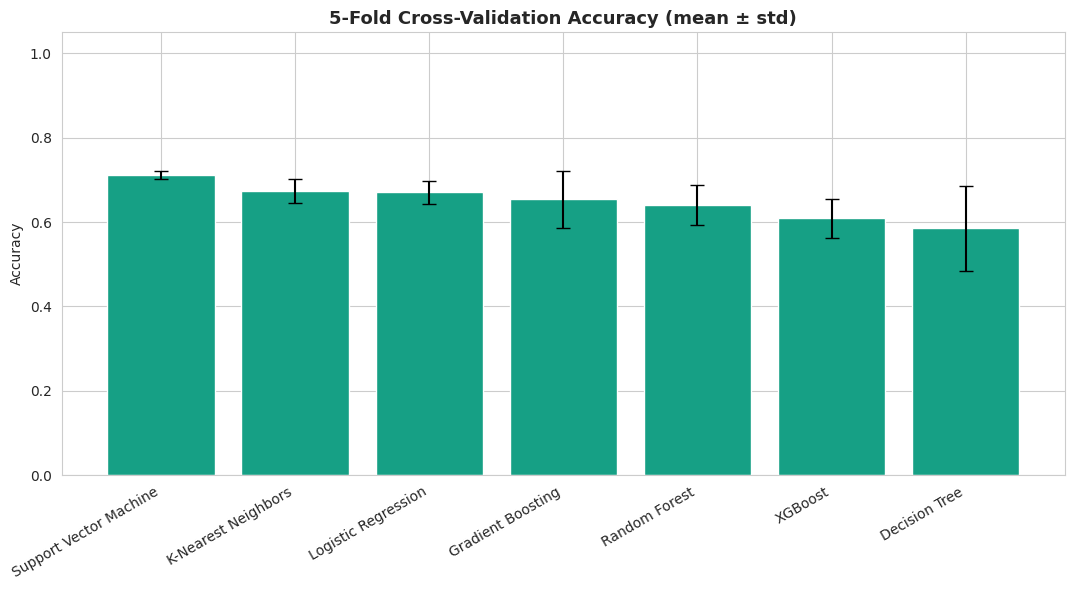

In [46]:
plt.figure(figsize=(11, 6))
plt.bar(cv_results_df['Model'], cv_results_df['CV Mean Accuracy'],
        yerr=cv_results_df['CV Std Dev'], capsize=5, color='#16a085')
plt.title('5-Fold Cross-Validation Accuracy (mean ± std)', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


### 18.2 Hyperparameter Tuning with GridSearchCV

In [47]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("Best Hyperparameters found:", grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

tuned_rf_model = grid_search.best_estimator_
tuned_pred = tuned_rf_model.predict(X_test_scaled)
print(f"\nTest Accuracy of tuned model: {accuracy_score(y_test, tuned_pred):.4f}")
print(f"Test F1-Score of tuned model: {f1_score(y_test, tuned_pred, average='weighted'):.4f}")


Best Hyperparameters found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-Score: 0.6796

Test Accuracy of tuned model: 0.7253
Test F1-Score of tuned model: 0.6783


### 18.3 ROC-AUC Analysis (Multi-Class, One-vs-Rest)

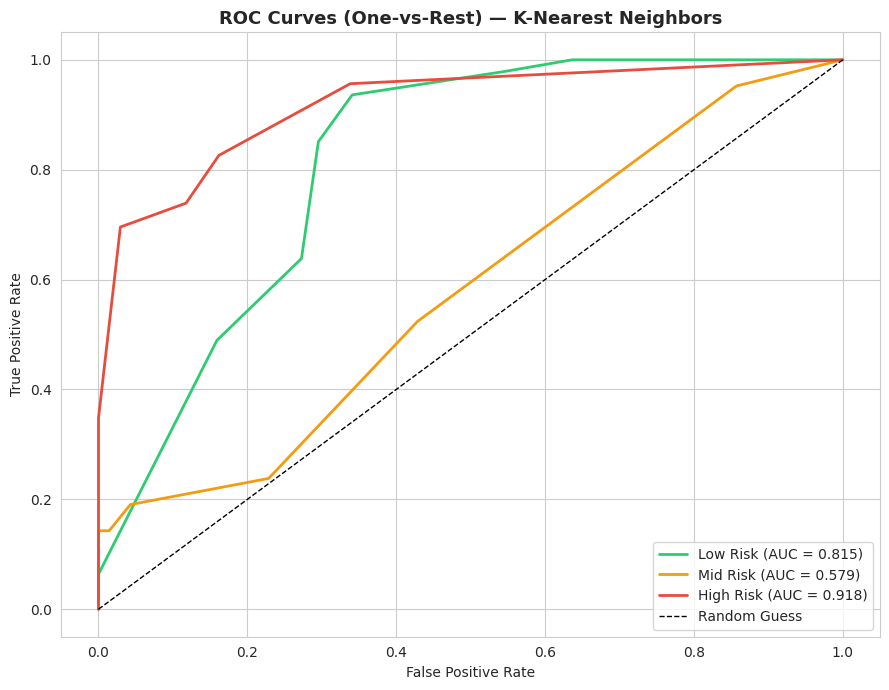

Overall Weighted ROC-AUC Score: 0.7865


In [48]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
class_names = ['Low Risk', 'Mid Risk', 'High Risk']

plt.figure(figsize=(9, 7))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

best_model_probs = best_model.predict_proba(X_test_scaled)

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_model_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves (One-vs-Rest) — {best_model_name}', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

overall_auc = roc_auc_score(y_test, best_model_probs, multi_class='ovr', average='weighted')
print(f"Overall Weighted ROC-AUC Score: {overall_auc:.4f}")


### 18.4 Learning Curves

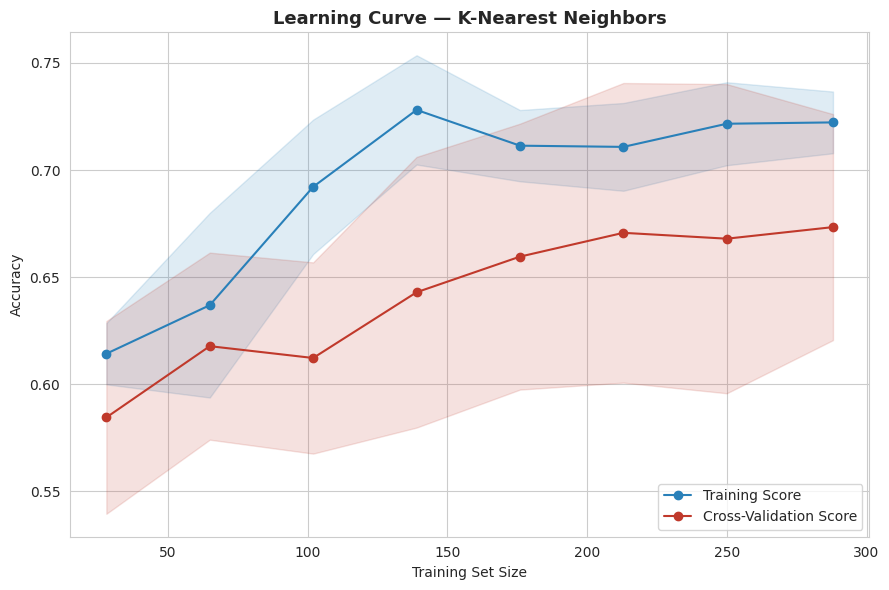

In [49]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring='accuracy', n_jobs=-1, random_state=42
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2980b9', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2980b9')
plt.plot(train_sizes, val_mean, 'o-', color='#c0392b', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#c0392b')

plt.title(f'Learning Curve — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 18.5 Feature Selection Analysis

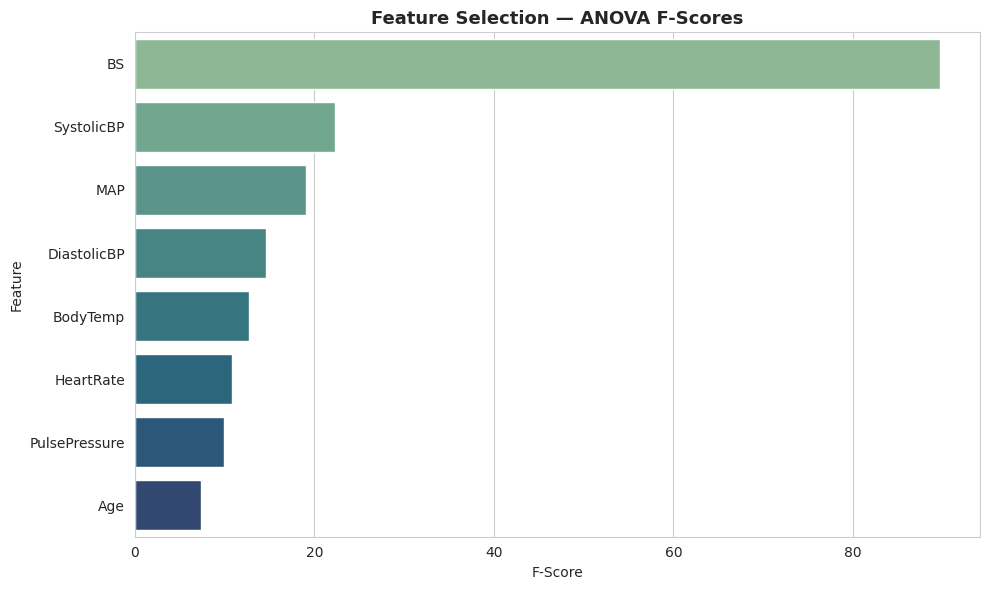

,Feature,F-Score,P-Value
0,BS,89.673534,2.688053e-32
1,SystolicBP,22.300603,7.454596e-10
2,MAP,19.098615,1.314967e-08
3,DiastolicBP,14.586567,8.128839e-07
4,BodyTemp,12.680056,4.779940e-06
5,HeartRate,10.798727,2.793784e-05
6,PulsePressure,9.982405,6.043200e-05
7,Age,7.338980,7.521902e-04


In [50]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_scores, x='F-Score', y='Feature', palette='crest')
plt.title('Feature Selection — ANOVA F-Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

feature_scores


## 19. Conclusion & Future Scope

### 📌 Project Summary
- Built a complete, end-to-end ML pipeline on the **UCI Maternal Health Risk
  Dataset**, covering EDA, feature engineering, preprocessing, multi-model
  training, and rigorous evaluation.
- Compared **7 classification algorithms** and selected the best performer
  (see `best_model_name` above) using weighted Accuracy, Precision, Recall,
  and F1-Score.
- Added **Explainable AI** (feature importance + SHAP) so predictions are
  transparent and clinically interpretable, not a "black box."
- Delivered a fully functional **Risk Prediction System**, **Healthcare
  Recommendation Engine**, and **Patient Health Report Generator** — moving
  beyond a static model into a usable decision-support prototype.
- Saved the production-ready model and scaler with both **Pickle** and
  **Joblib**, and validated that reloaded artifacts reproduce identical
  predictions.
- Strengthened the analysis with **cross-validation, hyperparameter tuning,
  ROC-AUC analysis, learning curves, and feature selection** — techniques
  expected of a strong applied ML practitioner.

### 🔭 Future Scope
- **Larger, more diverse datasets**: incorporate data across more
  geographies/hospitals to improve generalization.
- **Deep learning approaches**: experiment with neural networks for
  potentially richer feature interactions, especially if the dataset grows.
- **Real-time IoT integration**: connect the model to wearable sensors for
  continuous risk monitoring rather than point-in-time checkups.
- **Time-series modeling**: track a patient's vitals over the pregnancy
  trimester-by-trimester to detect deteriorating trends early.
- **Clinical validation**: partner with healthcare professionals to validate
  recommendations and calibrate thresholds before any real-world deployment.
- **Deployment**: wrap the saved model in a REST API (e.g., FastAPI/Flask)
  and a simple web or mobile front-end for use by clinics.

---

> ⚠️ **Important Disclaimer:** This project is for educational and portfolio
> purposes. It is **not** a certified medical device and must not be used for
> real clinical decision-making without proper validation, regulatory approval,
> and oversight by qualified healthcare professionals.
